<a href="https://colab.research.google.com/github/Lmessifan/Pytorch-Tutorial/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Convert Mnist image files into tensor of 4 dimensions (# of images, height, width, color channel)
transform = transforms.ToTensor()

In [ ]:
# Train Data
train_data = datasets.MNIST(root='/cnn_data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 349kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.16MB/s]


In [ ]:
#Test Data
test_data = datasets.MNIST(root='/cnn_data', train=False, download=True, transform=transform)

In [ ]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [ ]:
# Create a small batch size for images... lets say 10
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False)

In [ ]:
# Define CNN Model
# Describe Convolusional Layer and what it is doing (2 layers)
# just an example
conv1 = nn.Conv2d(1,6,3,1)
conv2 = nn.Conv2d(6,16,3,1)

In [ ]:
#Grab MNEST record
for i, (X_Train,y_train) in enumerate(train_data):
  break

In [ ]:
X_Train.shape

torch.Size([1, 28, 28])

In [ ]:
x = X_Train.view(1,1,28,28)

In [ ]:
#perform our first convolution
x = F.relu(conv1(x)) #Recfitifed Linear unit for our activation function


In [ ]:
#1 single image, 6 is the filters, 26
x.shape

torch.Size([1, 6, 26, 26])

In [ ]:
# pass thru the pooling layer
x = F.max_pool2d(x,2,2) #kernel of 2 and stride of 2

In [ ]:
x.shape # dividing by 2 i.e. 26/2 hence 13

torch.Size([1, 6, 13, 13])

In [ ]:
# 2nd convo layer
x = F.relu(conv2(x))

In [ ]:
x.shape #we didnt set padding and we lost 2 pixels around the image

torch.Size([1, 16, 11, 11])

In [ ]:
x = F.max_pool2d(x,2,2)

In [ ]:
x.shape # 11/2 = 5.5 but we have round it down, can't invent data to round up so we have to round it down

torch.Size([1, 16, 5, 5])

In [ ]:
# Model Class
class ConvolutionalNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1,6,3,1)
    self.conv2 = nn.Conv2d(6,16,3,1)
    # Fully connected layer
    self.fc1 = nn.Linear(5*5*16, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, X):
    X = F.relu(self.conv1(X))
    X = F.max_pool2d(X,2,2) #2*2 Kernal and Stride 2
    # 2nd pass
    X = F.relu(self.conv2(X))
    X = F.max_pool2d(X,2,2) #2*2 Kernal and Stride 2

    #Re-View to Flatten it
    X = X.view(-1, 16*5*5) # negative one so that we can vary the batch size

    # Fully Connected Layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.fc3(X)
    return F.log_softmax(X, dim=1)

In [ ]:
# Create an Instance of our Model
torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
# Loss Function Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #Smaller the learning rate, longer to it takes to train

In [ ]:
import time

start_time = time.time()

#create variables to track things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# For loop for epochs
for i in range(epochs):
  trn_corr = 0
  tst_corr = 0

  # Train
  for b,(X_train,y_train) in enumerate(train_loader):
    b+=1 #start our batches at 1
    y_pred = model(X_train) #get predicted values from the training set. Not flatenned cause it is 2d
    loss = criterion(y_pred,y_train) # how much off are we? compare predictions to corrent answers

    predicted = torch.max(y_pred.data,1)[1] # add up the number of correct predictions. Indexed of the first point
    batch_corr = (predicted == y_train).sum() # how many correct from the specific batch
    trn_corr += batch_corr #keep track as we go along in training.

    #Update out parameters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print out some results
    if b%600 == 0:
      print(f'Epoch : {i} Batch : {b}, Loss : {loss.item()}')

  train_losses.append(loss)
  train_correct.append(trn_corr)

  # Test
  with torch.no_grad(): # No gradient so we dont update our weights and biases with out test data
    for b,(X_test,y_test) in enumerate(test_loader):
      y_val = model(X_test)
      predicted = torch.max(y_val.data, 1)[1] #Adding up correct predictions
      tst_corr += (predicted == y_test).sum() # T=1 and F=0 and sum away

  loss = criterion(y_val,y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)

current_time = time.time()
total = current_time - start_time
print(f'Training Took : {total/60} minutes!')

Epoch : 0 Batch : 600, Loss : 0.006637142039835453
Epoch : 0 Batch : 1200, Loss : 0.00783450622111559
Epoch : 0 Batch : 1800, Loss : 0.0003394029045011848
Epoch : 0 Batch : 2400, Loss : 2.3446989871445112e-05
Epoch : 0 Batch : 3000, Loss : 0.00022752684890292585
Epoch : 0 Batch : 3600, Loss : 1.592533226357773e-05
Epoch : 0 Batch : 4200, Loss : 0.022726785391569138
Epoch : 0 Batch : 4800, Loss : 2.1707128325942904e-05
Epoch : 0 Batch : 5400, Loss : 0.10729362070560455
Epoch : 0 Batch : 6000, Loss : 0.04499586671590805
Epoch : 1 Batch : 600, Loss : 0.0024437110405415297
Epoch : 1 Batch : 1200, Loss : 0.016884196549654007
Epoch : 1 Batch : 1800, Loss : 0.2256944626569748
Epoch : 1 Batch : 2400, Loss : 0.00016805619816295803
Epoch : 1 Batch : 3000, Loss : 0.00020308113016653806
Epoch : 1 Batch : 3600, Loss : 0.00047115935012698174
Epoch : 1 Batch : 4200, Loss : 0.0002691078989300877
Epoch : 1 Batch : 4800, Loss : 0.005151991732418537
Epoch : 1 Batch : 5400, Loss : 0.017210768535733223
Epo

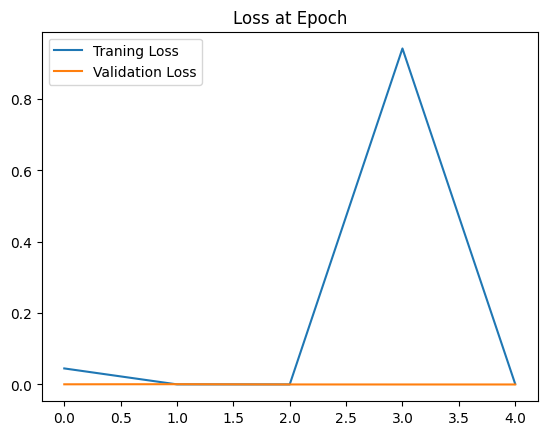

In [ ]:
# Graph the loss at each epoch
train_losses = [tl.item() for tl in train_losses]
plt.plot(train_losses, label='Traning Loss')
plt.plot(test_losses, label='Validation Loss')
plt.title('Loss at Epoch')
plt.legend()

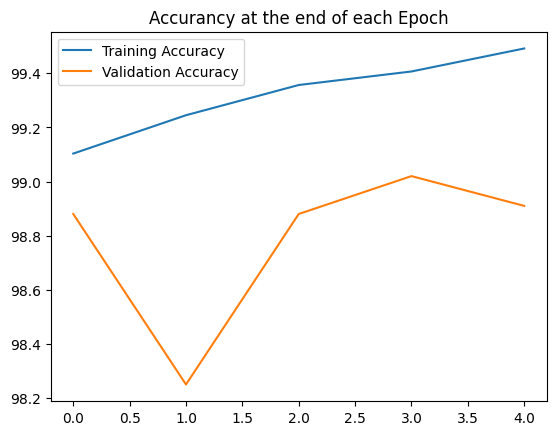

In [ ]:
# graph the accuracy
plt.plot([t/600 for t in train_correct], label = 'Training Accuracy')
plt.plot([t/100 for t in test_correct], label = 'Validation Accuracy')
plt.title('Accurancy at the end of each Epoch')
plt.legend()

In [ ]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

In [ ]:
with torch.no_grad():
  correct = 0
  for X_test, y_test in test_load_everything:
    y_val = model(X_test)
    predicted = torch.max(y_val,1)[1]
    correct += (predicted == y_test).sum()


In [ ]:
# Old for correct
correct.item()/len(test_data)*100

98.91

In [ ]:
# Grab an image
test_data[414] #a tensor with an image in it... in end with a label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
# grab the data
input = test_data[4141][0]

In [ ]:
# Reshape this guy
input.reshape(28,28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

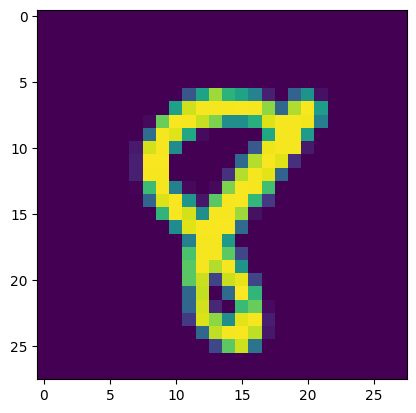

In [ ]:
# show the image
plt.imshow(input.reshape(28,28))

In [ ]:
# Lets pass the image through our model
model.eval()
with torch.no_grad():
  new_prediction = model(input.view(1,1,28,28)) # batch size of 1, 1 color channel, 28*28 image

In [ ]:
new_prediction

tensor([[-2.3090e+01, -2.1618e+01, -2.4082e+01, -1.4158e+01, -2.8724e+01,
         -1.6443e+01, -1.8874e+01, -2.6514e+01, -8.3446e-07, -1.8107e+01]])

In [ ]:
new_prediction.argmax()

tensor(8)